In [25]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")


EDA

In [26]:
DATA_PATH = r"C:\Users\MOHAMED ALI REBBAH\Documents\GitHub\When-ML-fails\data\online_shoppers_intention.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()


(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [28]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [29]:
df.describe()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [30]:
df.describe(include='str')

,Month,VisitorType
count,12330,12330
unique,10,3
top,May,Returning_Visitor
freq,3364,10551


Target Distribution

In [31]:
df['Revenue'].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [32]:
df['Revenue'].value_counts(normalize=True)*100

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

Class Distribution

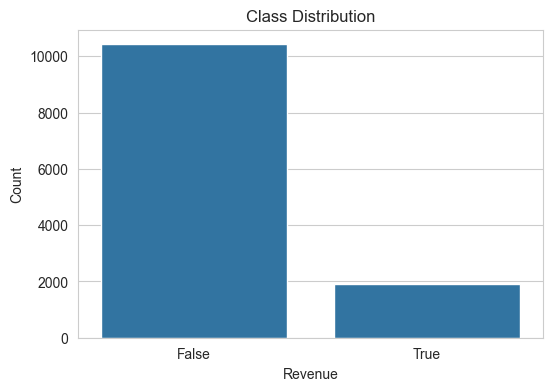

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Revenue')

plt.title("Class Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")

plt.show()

Separating Numerical and Categorical Features

In [46]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_features = df.select_dtypes(include=['str', 'bool']).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical Features:
['Month', 'VisitorType', 'Weekend', 'Revenue']


Checking Unique Values in Categoricals

In [48]:
for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True)*100)


Month
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64
Month
May     27.283049
Nov     24.314680
Mar     15.466342
Dec     14.006488
Oct      4.452555
Sep      3.633414
Aug      3.511760
Jul      3.503650
June     2.335766
Feb      1.492295
Name: proportion, dtype: float64

VisitorType
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64
VisitorType
Returning_Visitor    85.571776
New_Visitor          13.738848
Other                 0.689376
Name: proportion, dtype: float64

Weekend
Weekend
False    9462
True     2868
Name: count, dtype: int64
Weekend
False    76.739659
True     23.260341
Name: proportion, dtype: float64

Revenue
Revenue
False    10422
True      1908
Name: count, dtype: int64
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


Correlation Heatmap

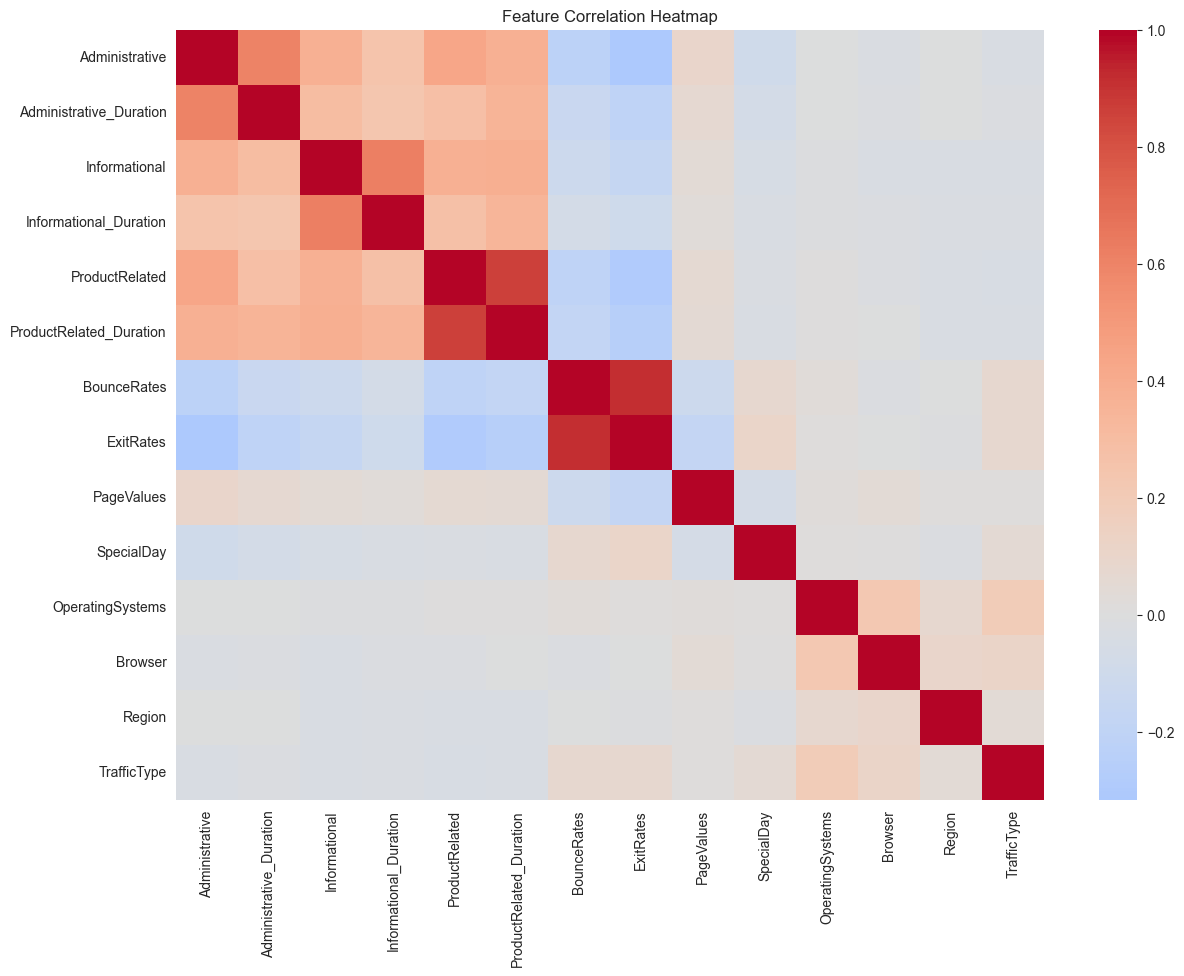

In [36]:
plt.figure(figsize=(14,10))

corr = df[numerical_features].corr()

sns.heatmap(corr, cmap='coolwarm', center=0)

plt.title("Feature Correlation Heatmap")

plt.show()

**Looking for temporal shortcut effect**

In [53]:
month_conversion = (
    df.groupby('Month')['Revenue']
    .mean()
    .sort_values()
)

month_conversion

Month
Feb     0.016304
Mar     0.100682
June    0.100694
May     0.108502
Dec     0.125072
Jul     0.152778
Aug     0.175520
Sep     0.191964
Oct     0.209472
Nov     0.253502
Name: Revenue, dtype: float64

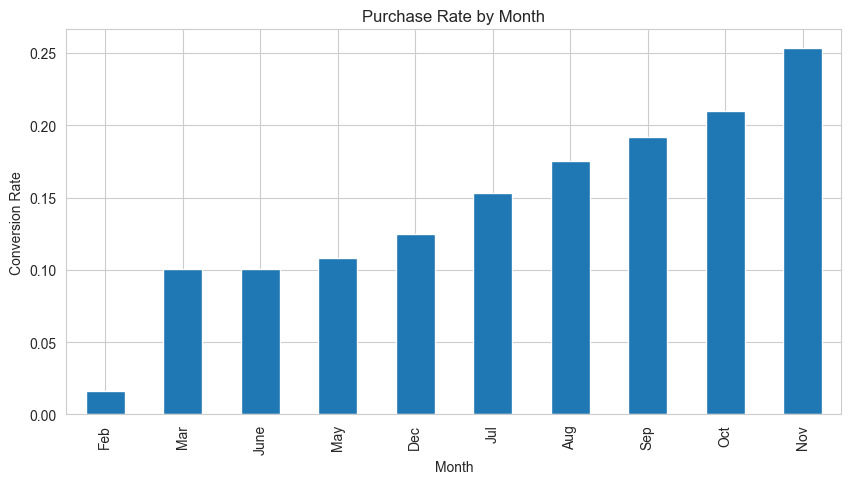

In [38]:
plt.figure(figsize=(10,5))

month_conversion.plot(kind='bar')

plt.title("Purchase Rate by Month")
plt.ylabel("Conversion Rate")
plt.xlabel("Month")

plt.show()

_there is massive difference. there is a shortcut learning risk. for example the model could learn: if we are near the end of the year it's likely a purchase_

In [39]:
traffic_conversion = (
    df.groupby('TrafficType')['Revenue']
    .mean()
    .sort_values(ascending=False)
)

traffic_conversion.head(10)

TrafficType
16    0.333333
7     0.300000
8     0.276968
20    0.252525
2     0.216458
5     0.215385
10    0.200000
11    0.190283
4     0.154350
14    0.153846
Name: Revenue, dtype: float64

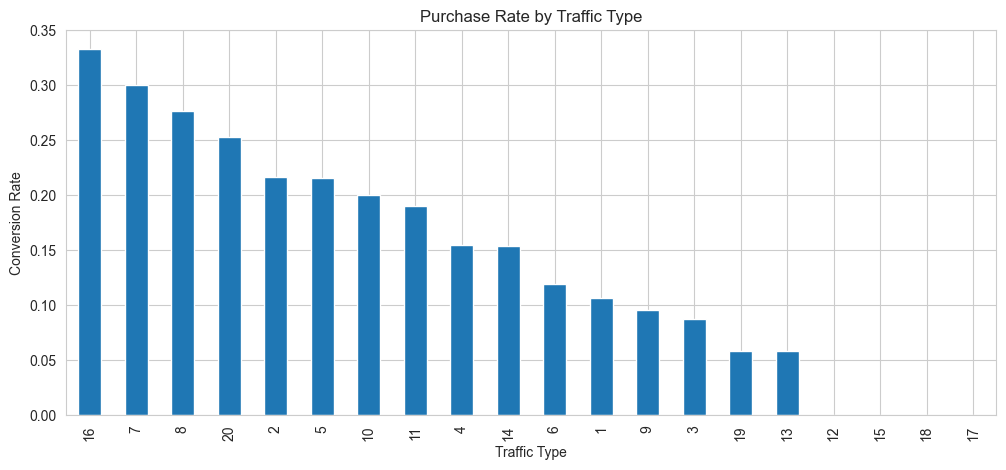

In [40]:
plt.figure(figsize=(12,5))

traffic_conversion.plot(kind='bar')

plt.title("Purchase Rate by Traffic Type")
plt.ylabel("Conversion Rate")
plt.xlabel("Traffic Type")

plt.show()

_this also could lead to a shortcut effect_

In [41]:
visitor_conversion = (
    df.groupby('VisitorType')['Revenue']
    .mean()
)

visitor_conversion

VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

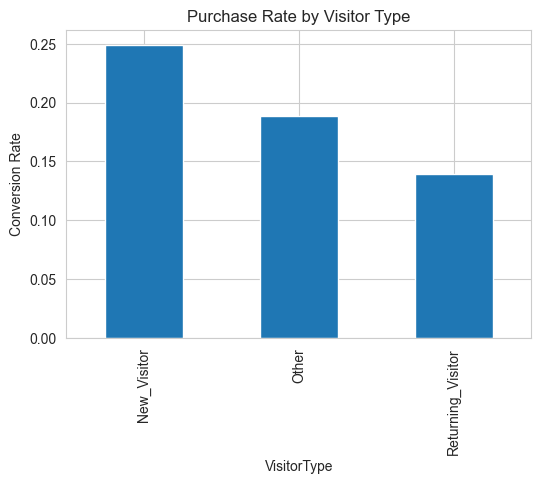

In [42]:
plt.figure(figsize=(6,4))

visitor_conversion.plot(kind='bar')

plt.title("Purchase Rate by Visitor Type")
plt.ylabel("Conversion Rate")

plt.show()

_Usually returning visitors convert more maybe it's due to marketing campaign bias but not necessarily a shortcut effect_

**Behavioral Features vs Revenue**

ProductRelatedDuration

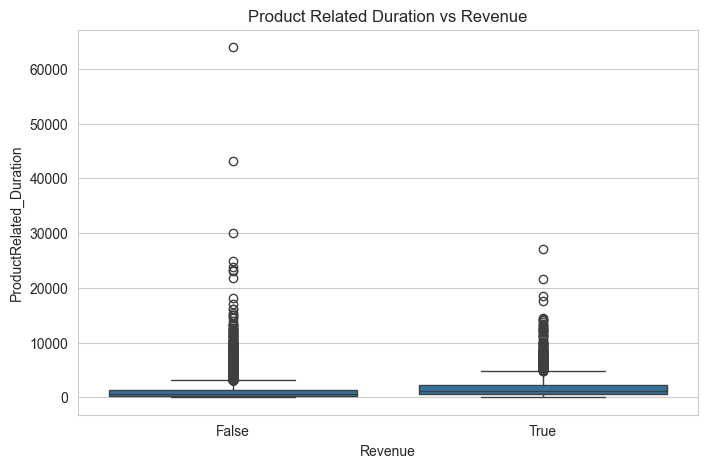

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Revenue',
    y='ProductRelated_Duration'
)

plt.title("Product Related Duration vs Revenue")

plt.show()

Bounce Rate vs Revenue

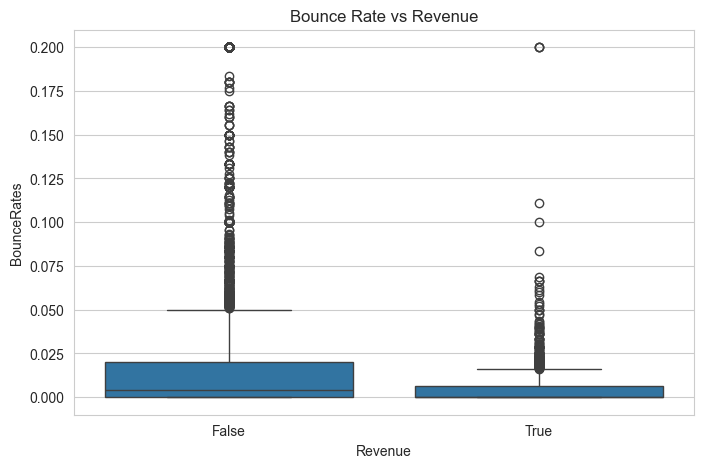

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Revenue',
    y='BounceRates'
)

plt.title("Bounce Rate vs Revenue")

plt.show()

_engaged users browse more before purchasing also there is no near separation this is likely a genuine behavioral signal_

Investigating PageValue

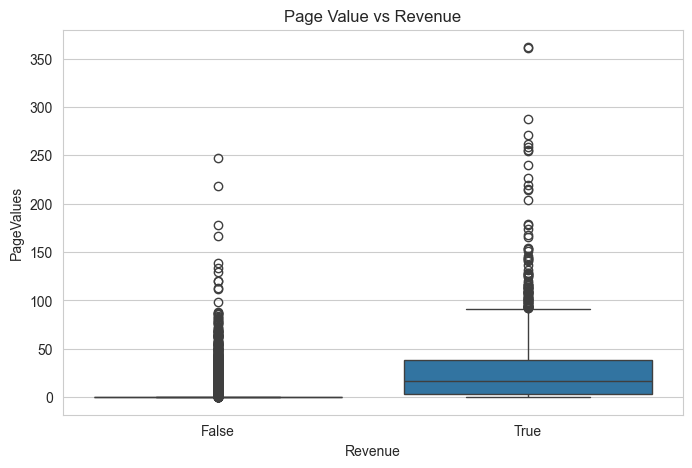

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Revenue',
    y='PageValues'
)

plt.title("Page Value vs Revenue")

plt.show()

_average value of pages visited before a transaction is higher for true and near 0 for false meaning that this feature is highly predictive of revenue there for it will be removed from our pipline so that we can catch the shortcut effect related to temporal and traffic-source features_